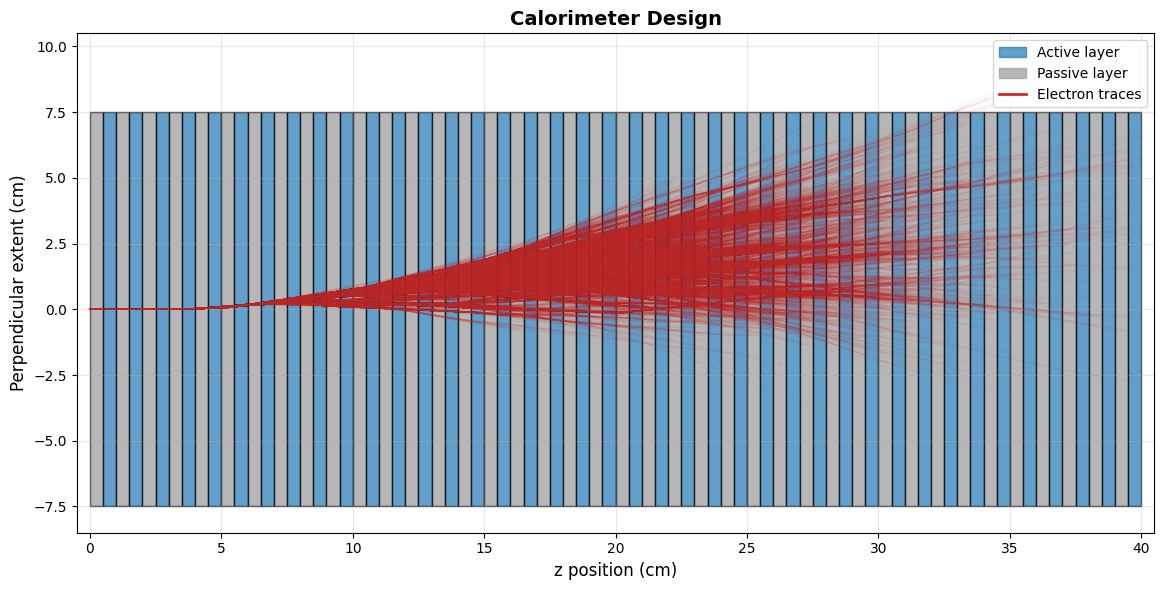

In [19]:
import random
import time
import math

import matplotlib.pyplot as plt
import numpy as np
import monashspa.PHS3302.calorimeter.model as model

from scipy.optimize import curve_fit

from scipy import stats
from monashspa.common.fitting import (
    get_fit_parameters,
    make_lmfit_model,
    model_fit,
)


mycal = model.Calorimeter()

lead = model.Layer("lead", 2.0, 0.5, 0.0)
scintillator = model.Layer("Scin", 0.01, 0.5, 1.0)

for _ in range(40):
    mycal.add_layers([lead, scintillator])

sim = model.Simulation(mycal)

# ---- First single-particle tracing simulation ----
ionisations, cal_with_traces = sim.simulate_with_tracing(
    model.Electron(0, 100), deadcellfraction=0.0
)

fig, ax = plt.subplots(figsize=(14, 6))
cal_with_traces.draw(ax=ax, show_traces=True)
plt.tight_layout()
plt.show()

# ---- Reset before the sample simulation ----
mycal.reset()


Simulation took 0.0177 seconds per particle
Relative resolution is 0.023


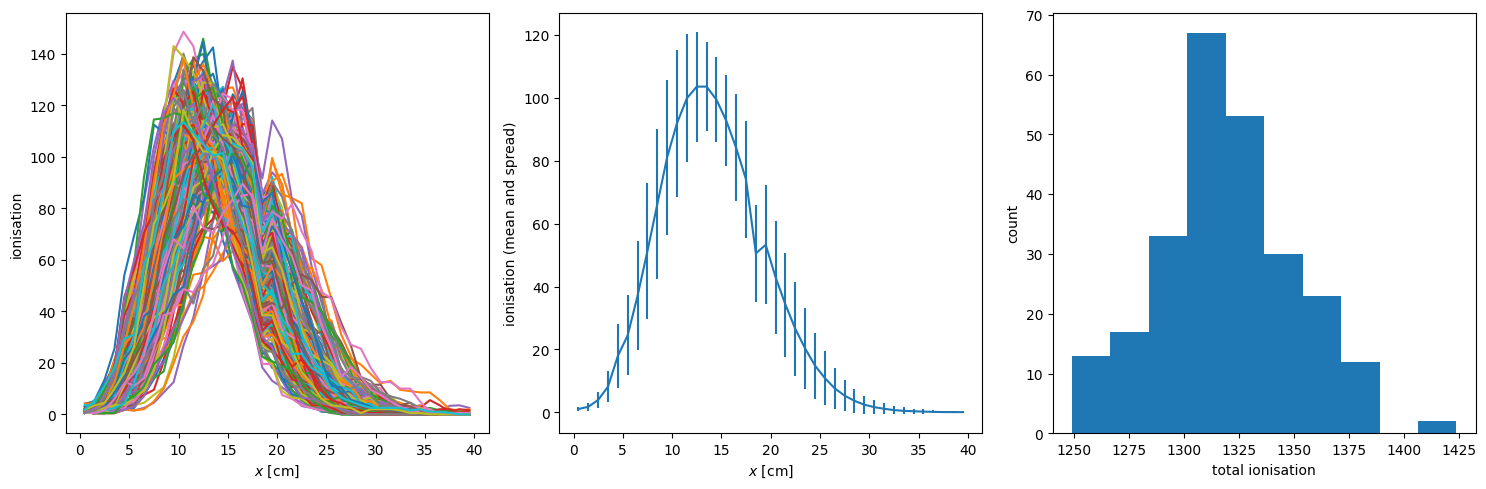

In [2]:

start_time = time.time()

spectrum = model.Spectrum(particle_type=model.Electron)
electrons = spectrum.discrete(n_particles=250, energy=10.0)

ionisations = sim.simulate_sample(electrons, deadcellfraction=0.0)

elapsed_time = time.time() - start_time

energies = np.sum(ionisations, axis=1)
rel_resolution = np.std(energies) / np.mean(energies)

print(f"Simulation took {elapsed_time / len(electrons):.4f} seconds per particle")
print(f"Relative resolution is {rel_resolution:.3f}")

# ---- Second plot: layer signals and energy distribution ----
meanionisations = np.mean(ionisations, axis=0)
rmsionisations = np.std(ionisations, axis=0)
zcors = [volume.z for volume in mycal.volumes(active=True)]

fig = plt.figure(figsize=(15, 5))
ax1, ax2, ax3 = fig.subplots(1, 3)

for event in ionisations:
  ax1.plot(zcors, event)

ax1.set_xlabel(r"$x$ [cm]")
ax1.set_ylabel("ionisation")

ax2.errorbar(zcors, meanionisations, yerr=rmsionisations)
ax2.set_xlabel(r"$x$ [cm]")
ax2.set_ylabel("ionisation (mean and spread)")

ax3.hist(energies)
ax3.set_xlabel("total ionisation")
ax3.set_ylabel("count")

plt.tight_layout()
plt.show()

Simulating 1 GeV electrons...
Simulating 2 GeV electrons...
Simulating 3 GeV electrons...
Simulating 4 GeV electrons...
Simulating 5 GeV electrons...
Simulating 6 GeV electrons...
Simulating 7 GeV electrons...
Simulating 8 GeV electrons...
Simulating 9 GeV electrons...
Simulating 10 GeV electrons...


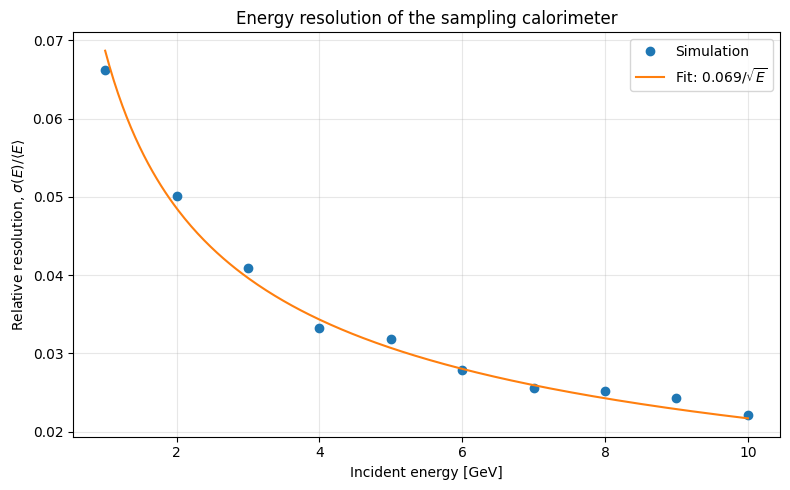

In [3]:
# # Your exercise should start here

# ## Study energy resolution
# Make a plot of the relative energy resolution, $\sigma(E)/E$ for particles between 1 and 10 GeV.
# You should be able to demonstrate that the resolution is proportional to $1/\sqrt{E}$.


beam_energies = np.arange(1.0, 11.0, 1.0)  # 1, 2, ..., 10 GeV
n_particles_per_energy = 250

relative_resolutions = []

for beam_energy in beam_energies:
    print(f"Simulating {beam_energy:.0f} GeV electrons...")

    # Generate n_particles_per_energy electrons with identical true energy.
    study_spectrum = model.Spectrum(
        particle_type=model.Electron, min_energy=1.0, max_energy=10.0
    )
    electrons = study_spectrum.discrete(
        n_particles=n_particles_per_energy, energy=beam_energy
    )

    # ionisations has one row per electron and one column per active layer.
    ionisations = sim.simulate_sample(electrons, deadcellfraction=0.0)

    # Reconstructed calorimeter signal for every event.
    reconstructed_energies = np.sum(ionisations, axis=1)

    # Relative energy resolution: sigma(E_reco) / mean(E_reco).
    resolution = np.std(reconstructed_energies, ddof=1) / np.mean(
        reconstructed_energies
    )

    relative_resolutions.append(resolution)

relative_resolutions = np.array(relative_resolutions)

def resolution_model(energy, a):
    """Resolution model: sigma(E)/E = a / sqrt(E)."""
    return a / np.sqrt(energy)

fit_parameters, _ = curve_fit(resolution_model, beam_energies, relative_resolutions)

a_fit = fit_parameters[0]

energy_smooth = np.linspace(1.0, 10.0, 300)

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(beam_energies, relative_resolutions, "o", label="Simulation")
ax.plot(
    energy_smooth,
    resolution_model(energy_smooth, a_fit),
    label=rf"Fit: ${a_fit:.3f}/\sqrt{{E}}$",
)

ax.set_xlabel("Incident energy [GeV]")
ax.set_ylabel(r"Relative resolution, $\sigma(E)/\langle E\rangle$")
ax.set_title("Energy resolution of the sampling calorimeter")
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()


# 2 marks: Sum the ionisations to get the total energy deposited in the calorimeter for each electron
# 2 marks: Create plot of the relative energy resolution vs. energy
# 2 marks: Document that it shows the $1/\sqrt{E}$ behaviour through a fit or similar

Simulating 1 GeV electrons with readout noise...
Mean layer signal: 40.13908747102575
Median layer signal: 26.0000000000001
Mean total signal per event: 1316.0803999999926
Number of active layers per event: 32.788
Simulating 2 GeV electrons with readout noise...
Simulating 3 GeV electrons with readout noise...
Simulating 4 GeV electrons with readout noise...
Simulating 5 GeV electrons with readout noise...
Simulating 6 GeV electrons with readout noise...
Simulating 7 GeV electrons with readout noise...
Simulating 8 GeV electrons with readout noise...
Simulating 9 GeV electrons with readout noise...
Simulating 10 GeV electrons with readout noise...


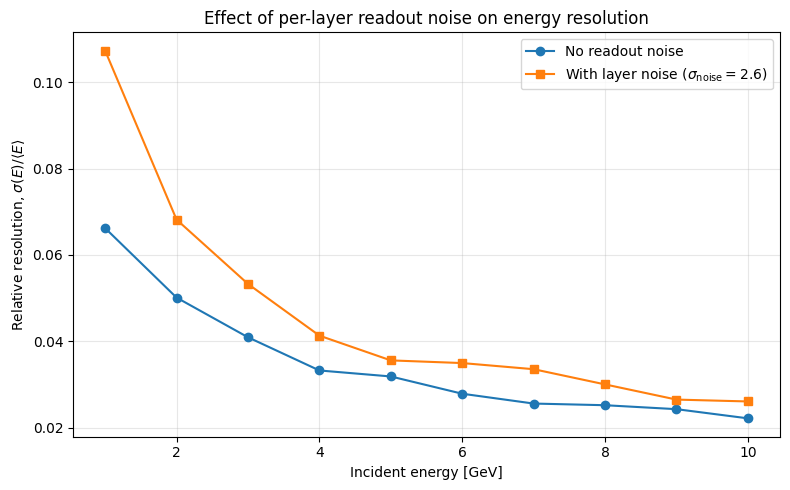

In [4]:
# ## Noise
# Modify the code such that when reading out the total ionisation from a layer, a noise term is added.
# The noise is a random amount from a Gaussian distribution that is added to the ionisation for active
# layers. Demonstrate how this is only relevant for the relative resolution when the ingoing particle
# has low energy. Identify a noise level yourself that illustrates the effect well.

# 2 marks. Add noise term correctly as an additive term on a per layer basis.
# 2 marks: Create aplot that shows the new relative energy resolution.
# 2 marks: Comparison in one form or the other to situation without the noise.

# Fixed seed so that the result is reproducible.
rng = np.random.default_rng(33739374)

# Standard deviation of the readout noise per active calorimeter layer.
# Based on median layer signal of 26
noise_sigma_per_layer = 2.6

relative_resolutions_noise = []

for beam_energy in beam_energies:
    print(f"Simulating {beam_energy:.0f} GeV electrons with readout noise...")

    if beam_energy == 1.0:
        active_values = ionisations[ionisations > 0]

        print("Mean layer signal:", np.mean(active_values))
        print("Median layer signal:", np.median(active_values))
        print("Mean total signal per event:", np.mean(np.sum(ionisations, axis=1)))
        print(
            "Number of active layers per event:",
            np.mean(np.sum(ionisations > 0, axis=1)),
        )

    # Generate electrons with identical true incident energy.
    study_spectrum = model.Spectrum(
        particle_type=model.Electron,
        min_energy=1.0,
        max_energy=10.0,
    )
    electrons = study_spectrum.discrete(
        n_particles=n_particles_per_energy,
        energy=beam_energy,
    )

    # Shape: (number of events, number of calorimeter layers).
    # Each entry is the ionisation recorded in one layer for one event.
    ionisations = sim.simulate_sample(electrons, deadcellfraction=0.0)

    # Generate one independent Gaussian noise value for every layer
    # in every electron event. Mean = 0, standard deviation = noise_sigma_per_layer.
    layer_noise = rng.normal(
        loc=0.0,
        scale=noise_sigma_per_layer,
        size=ionisations.shape,
    )

    # Add noise only to active layers.
    # If an ionisation entry is zero, that layer is treated as inactive.
    noisy_ionisations = ionisations + layer_noise * (ionisations > 0)

    # Sum all noisy layer readouts to obtain one reconstructed energy per electron.
    reconstructed_energies_noise = np.sum(noisy_ionisations, axis=1)

    # Calculate sigma(E_reco) / mean(E_reco).
    resolution_noise = np.std(reconstructed_energies_noise, ddof=1) / np.mean(
        reconstructed_energies_noise
    )

    relative_resolutions_noise.append(resolution_noise)

relative_resolutions_noise = np.array(relative_resolutions_noise)

# Plot
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    beam_energies,
    relative_resolutions,
    "o-",
    label="No readout noise",
)

ax.plot(
    beam_energies,
    relative_resolutions_noise,
    "s-",
    label=rf"With layer noise ($\sigma_\mathrm{{noise}} = {noise_sigma_per_layer}$)",
)

ax.set_xlabel("Incident energy [GeV]")
ax.set_ylabel(r"Relative resolution, $\sigma(E)/\langle E\rangle$")
ax.set_title("Effect of per-layer readout noise on energy resolution")
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

Simulating 1.0 GeV electrons with mis-calibration
Simulating 2.0 GeV electrons with mis-calibration
Simulating 3.0 GeV electrons with mis-calibration
Simulating 4.0 GeV electrons with mis-calibration
Simulating 5.0 GeV electrons with mis-calibration
Simulating 6.0 GeV electrons with mis-calibration
Simulating 7.0 GeV electrons with mis-calibration
Simulating 8.0 GeV electrons with mis-calibration
Simulating 9.0 GeV electrons with mis-calibration
Simulating 10.0 GeV electrons with mis-calibration


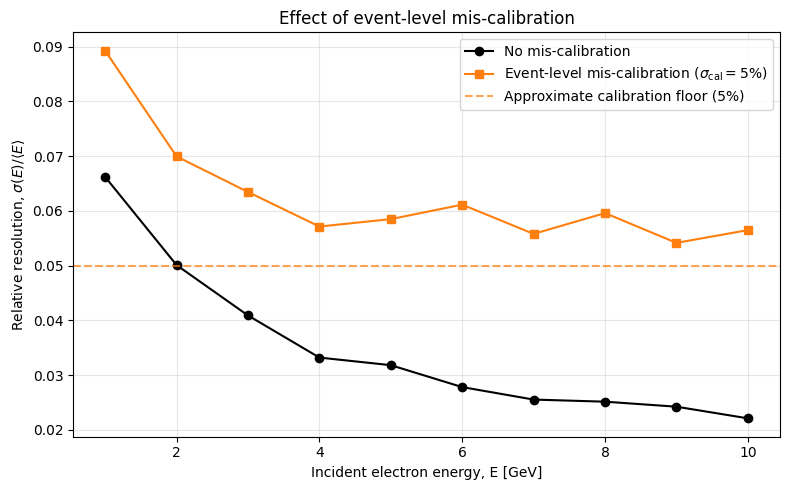

In [10]:
# ## Calibration
# Study how mis-calibration of layers will affect the resolution. Implement this by scaling the
# total ionisation collected in all layers for a given particle by a random value. The scaling factor
# should be close to 1.0. Demonstrate how this is most relevant for the relative resolution when the
# ingoing particle has high energy.

# 2 marks. Add calibration term correctly as a multiplicative term on the overall ionisation.
# 2 marks: Create a plot that shows the new relative energy resolution.
# 2 marks: Comparison in one form or the other to situation without the mis-calibration.

calibration_sigma = 0.05  # Can be adjusted

rng = np.random.default_rng(33739374)

relative_resolutions_calibration = []

for beam_energy in beam_energies:
    print(f"Simulating {beam_energy:.1f} GeV electrons with mis-calibration")

    electrons = study_spectrum.discrete(
        n_particles=n_particles_per_energy, energy=beam_energy
    )

    ionisations = sim.simulate_sample(electrons, deadcellfraction=0.0)

    # Total active scintillator signal per electron.
    reconstructed_energies = np.sum(ionisations, axis=1)

    # One calibration factor per electron event, centred on 1.0.
    calibration_factors = rng.normal(
        loc=1.0, scale=calibration_sigma, size=n_particles_per_energy
    )
    
    # Correct implementation: scale each event's total signal once.
    calibrated_energies = reconstructed_energies * calibration_factors

    resolution_calibration = np.std(calibrated_energies, ddof=1) / np.mean(
        calibrated_energies
    )

    relative_resolutions_calibration.append(resolution_calibration)

relative_resolutions_calibration = np.array(relative_resolutions_calibration)

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    beam_energies,
    relative_resolutions,
    "o-",
    color="black",
    label="No mis-calibration",
)

ax.plot(
    beam_energies,
    relative_resolutions_calibration,
    "s-",
    color="tab:orange",
    label=(
        "Event-level mis-calibration "
        f"($\\sigma_{{\\rm cal}}={100 * calibration_sigma:.0f}\\%$)"
    ),
)

ax.axhline(
    calibration_sigma,
    color="tab:orange",
    linestyle="--",
    alpha=0.7,
    label=("Approximate calibration " f"floor ({100 * calibration_sigma:.0f}%)"),
)

ax.set_xlabel("Incident electron energy, E [GeV]")
ax.set_ylabel(
    r"Relative resolution, $\sigma(E)/\langle E\rangle$"
)
ax.set_title("Effect of event-level mis-calibration")
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

Simulating 1.0 GeV with noise and calibration
Simulating 1.5 GeV with noise and calibration
Simulating 2.0 GeV with noise and calibration
Simulating 3.0 GeV with noise and calibration
Simulating 4.0 GeV with noise and calibration
Simulating 5.0 GeV with noise and calibration
Simulating 7.5 GeV with noise and calibration
Simulating 10.0 GeV with noise and calibration
Simulating 12.5 GeV with noise and calibration
Simulating 15.0 GeV with noise and calibration
Simulating 17.5 GeV with noise and calibration
Simulating 20.0 GeV with noise and calibration

Overall calorimeter energy resolution
chi-square / dof = 12.36 / 9 = 1.37
p-value = 0.194

[[Model]]
    Model(custom_model_function_5)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 29
    # data points      = 12
    # variables        = 3
    chi-square         = 12.3555569
    reduced chi-square = 1.37283966
    Akaike info crit   = 6.35039121
    Bayesian info crit = 7.80511115
    R-squared          = 0.

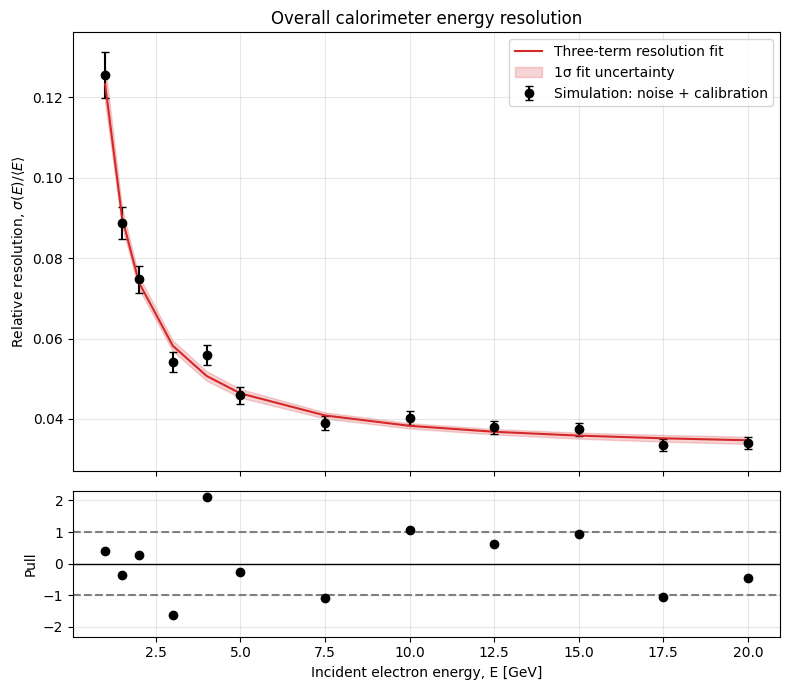

In [7]:
# ## Fit an overall resolution
# 
# Put everything together, so that you have a simulation that considers both noise and calibration.
# Implement a fit that determines the a, b anc c parameters of a calorimeter resolution model:
# $\frac{\sigma(E)}{E} = \frac{a}{\sqrt{E}} \oplus b \oplus \frac{c}{E}$.


particle_energies = np.array(
    [1.0, 1.5, 2.0, 3.0, 4.0, 5.0, 7.5, 10.0, 12.5, 15.0, 17.5, 20.0]
)

n_particles_per_energy = 250

# Use the values you selected in your earlier two sections.
noise_sigma = 2.0
calibration_sigma = 0.03

study_spectrum_all = model.Spectrum(
    particle_type=model.Electron,
    min_energy=float(np.min(particle_energies)),
    max_energy=float(np.max(particle_energies)),
)

rng = np.random.default_rng(33739374)

rel_resolutions_withall = []
u_rel_resolutions_withall = []

for beam_energy in particle_energies:
    print(f"Simulating {beam_energy:.1f} GeV with noise and calibration")

    electrons = study_spectrum_all.discrete(
        n_particles=n_particles_per_energy, energy=float(beam_energy)
    )

    ionisations = sim.simulate_sample(electrons, deadcellfraction=0.0)

    # --- Add independent Gaussian readout noise to each active layer ---
    noisy_ionisations = ionisations + rng.normal(
        loc=0.0, scale=noise_sigma, size=ionisations.shape
    )

    # --- Sum active layers to get one reconstructed signal per event ---
    reconstructed_energies = np.sum(noisy_ionisations, axis=1)

    # --- Apply one multiplicative calibration factor per event ---
    calibration_factors = rng.normal(
        loc=1.0, scale=calibration_sigma, size=n_particles_per_energy
    )

    reconstructed_energies *= calibration_factors

    # --- Measure the resolution at this known incident energy ---
    resolution = np.std(reconstructed_energies, ddof=1) / np.mean(
        reconstructed_energies
    )

    # Approximate statistical uncertainty from the finite number of events.
    u_resolution = resolution / np.sqrt(2 * (n_particles_per_energy - 1))

    rel_resolutions_withall.append(resolution)
    u_rel_resolutions_withall.append(u_resolution)

rel_resolutions_withall = np.array(rel_resolutions_withall)
u_rel_resolutions_withall = np.array(u_rel_resolutions_withall)

name = "Overall calorimeter energy resolution"

res_model = make_lmfit_model("sqrt(a*a/x + b*b + c*c/(x*x))")

params = res_model.make_params(a=0.09, b=calibration_sigma, c=3)

fit_results = model_fit(
    res_model,
    params,
    particle_energies,
    rel_resolutions_withall,
    u_y=u_rel_resolutions_withall,
)

fit = fit_results.best_fit
u_fit = fit_results.eval_uncertainty(sigma=1)

pvalue = 1.0 - stats.chi2.cdf(
    fit_results.chisqr, fit_results.ndata - fit_results.nvarys
)

print(f"\n{name}")
print("=" * len(name))
print(
    f"chi-square / dof = {fit_results.chisqr:.2f} / "
    f"{fit_results.ndata - fit_results.nvarys} = {fit_results.chisqr/(fit_results.ndata - fit_results.nvarys):.2f}"
)
print(f"p-value = {pvalue:.3g}\n")
print(fit_results.fit_report())

fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(8, 7), sharex=True, gridspec_kw={"height_ratios": [3, 1]}
)

ax1.errorbar(
    particle_energies,
    rel_resolutions_withall,
    yerr=u_rel_resolutions_withall,
    marker="o",
    linestyle="None",
    color="black",
    capsize=3,
    label="Simulation: noise + calibration",
)

ax1.plot(
    particle_energies,
    fit,
    linestyle="-",
    color="tab:red",
    label="Three-term resolution fit",
)

ax1.fill_between(
    particle_energies,
    fit - u_fit,
    fit + u_fit,
    color="tab:red",
    alpha=0.2,
    label="1σ fit uncertainty",
)

ax1.set_ylabel(
    r"Relative resolution, $\sigma(E)/\langle E\rangle$"
)
ax1.set_title("Overall calorimeter energy resolution")
ax1.grid(alpha=0.3)
ax1.legend()

pull = (rel_resolutions_withall - fit) / u_rel_resolutions_withall

ax2.axhline(0, color="black", linewidth=1)
ax2.axhline(1, color="grey", linestyle="--")
ax2.axhline(-1, color="grey", linestyle="--")

ax2.plot(particle_energies, pull, marker="o", linestyle="None", color="black")

ax2.set_xlabel("Incident electron energy, E [GeV]")
ax2.set_ylabel("Pull")
ax2.grid(alpha=0.3)

pull_scale = max(1.5, 1.1 * np.max(np.abs(pull)))
ax2.set_ylim(-pull_scale, pull_scale)

plt.tight_layout()
plt.show()

# 2 marks. Simulate data with both noise and mis-calibration
# 2 marks: Fit the simulated data
# 3 marks: Interpret results by discussing the shape of the graphs and commenting on the fit.

if False:
    # Fill these arrays with the relative resolution and the uncertainty on that estimate for each of the
    # particle energies
    rel_resolutions_withall = []
    u_rel_resolutions_withall = []

    name = "Energy resolution"
    res_model = make_lmfit_model("sqrt(a*a/x + b*b + c*c/(x*x))")
    params = res_model.make_params(a=0.09, b=0.03, c=3)
    fit_results = model_fit(
        res_model,
        params,
        particle_energies,
        rel_resolutions_withall,
        u_y=u_rel_resolutions_withall,
    )

    # Extract result and print nicely
    fit = fit_results.best_fit
    u_fit = fit_results.eval_uncertainty(sigma=1)
    fit_parameters = get_fit_parameters(fit_results)
    pvalue = 1.0 - stats.chi2.cdf(
        fit_results.chisqr, fit_results.ndata - fit_results.nvarys
    )

    print("""
    [[{name}]]
    =================
    p-value       = {pvalue:.2E}
    """.format(name=name, pvalue=pvalue))
    print(fit_results.fit_report())

    # Create some plots
    fig, (ax1, ax2) = plt.subplots(
        2, sharex=True, gridspec_kw={"height_ratios": [3, 1]}
    )
    ax1.errorbar(
        particle_energies,
        rel_resolutions_withall,
        yerr=u_rel_resolutions_withall,
        marker="x",
        linestyle="None",
        color="black",
        label="Energy resolution",
    )
    ax1.plot(
        particle_energies,
        fit,
        marker="None",
        linestyle="-",
        color="black",
        label="fit to {name}".format(name=name),
    )
    ax1.fill_between(
        particle_energies,
        fit - u_fit,
        fit + u_fit,
        color="lightgrey",
        label="uncertainty in {name}".format(name=name),
    )
    ax1.legend(bbox_to_anchor=(0.3, 1))
    ax1.set(ylabel="resolution")
    pull = (rel_resolutions_withall - fit) / u_rel_resolutions_withall
    ax2.plot(particle_energies, pull, marker="*", linestyle="None", color="black")
    emin = np.min(particle_energies)
    emax = np.max(particle_energies)
    ax2.plot([emin, emax], [0, 0], marker="None", linestyle="-", color="grey")
    ax2.plot([emin, emax], [1, 1], marker="None", linestyle="dashed", color="grey")
    ax2.plot(
        [emin, emax], [-1, -1], marker="None", linestyle="dashed", color="grey"
    )
    ax2.set(xlabel="x", ylabel="Pull")
    scale = 1.1 * np.max(np.abs(pull))
    ax2.set_ylim(-scale, scale)
    fig.suptitle("Fit with {name}".format(name=name))

    plt.show()

In [16]:
# Helper functions for part 5
def build_uniform_calorimeter(n_pairs):
    """
    Build a uniform lead-scintillator calorimeter.

    Total material is fixed to:
        80.0 cm lead
        0.40 cm scintillator

    n_pairs must be between 1 and 40.
    """
    if not 1 <= n_pairs <= 40:
        raise ValueError("n_pairs must be between 1 and 40.")

    calorimeter = model.Calorimeter()

    lead_thickness = 80.0 / n_pairs
    scintillator_thickness = 0.40 / n_pairs

    lead = model.Layer("lead", lead_thickness, 0.5, 0.0)
    scintillator = model.Layer("Scin", scintillator_thickness, 0.5, 1.0)

    for _ in range(n_pairs):
        calorimeter.add_layers([lead, scintillator])

    return calorimeter


def build_nonuniform_calorimeter():
    """
    Non-uniform configuration:
    - First 20 lead plates: 1.0 cm each
    - Last 20 lead plates: 3.0 cm each
    - All 40 scintillator sheets: 0.01 cm each

    Total lead = 20*1.0 + 20*3.0 = 80.0 cm
    Total scintillator = 40*0.01 = 0.40 cm
    """
    calorimeter = model.Calorimeter()

    lead_front = model.Layer("lead", 1.0, 0.5, 0.0)
    lead_back = model.Layer("lead", 3.0, 0.5, 0.0)
    scintillator = model.Layer("Scin", 0.01, 0.5, 1.0)

    for _ in range(20):
        calorimeter.add_layers([lead_front, scintillator])

    for _ in range(20):
        calorimeter.add_layers([lead_back, scintillator])

    return calorimeter

def build_nonuniform_calorimeter_v2():
    """
    Non-uniform configuration:
    - First 10 lead plates: 3.0 cm each
    - Next 20 lead plates: 1.0 cm each
    - Last 10 lead plates: 3.0 cm each
    - All 40 scintillator sheets: 0.01 cm each

    Total lead = 10*3.0 + 20*1.0 + 10*3.0 = 80.0 cm
    Total scintillator = 40*0.01 = 0.40 cm
    """
    calorimeter = model.Calorimeter()

    lead_front = model.Layer("lead", 1.0, 0.5, 0.0)
    lead_back = model.Layer("lead", 3.0, 0.5, 0.0)
    scintillator = model.Layer("Scin", 0.01, 0.5, 1.0)

    for _ in range(10):
        calorimeter.add_layers([lead_back, scintillator])

    for _ in range(20):
        calorimeter.add_layers([lead_front, scintillator])

    for _ in range(10):
        calorimeter.add_layers([lead_back, scintillator])

    return calorimeter


def simulate_resolution_curve(
    simulation,
    spectrum,
    particle_energies,
    n_particles_per_energy,
    noise_sigma,
    calibration_sigma,
    seed=33739374,
):
    rng = np.random.default_rng(seed)

    resolutions = []
    uncertainties = []

    for beam_energy in particle_energies:
        electrons = spectrum.discrete(
            n_particles=n_particles_per_energy, energy=float(beam_energy)
        )

        ionisations = simulation.simulate_sample(electrons, deadcellfraction=0.0)

        # Independent additive readout noise in every active layer.
        noisy_ionisations = ionisations + rng.normal(
            loc=0.0, scale=noise_sigma, size=ionisations.shape
        )

        # Total reconstructed signal per event.
        reconstructed_energies = np.sum(noisy_ionisations, axis=1)

        # One event-level multiplicative calibration factor.
        calibration_factors = rng.normal(
            loc=1.0, scale=calibration_sigma, size=n_particles_per_energy
        )

        reconstructed_energies *= calibration_factors

        resolution = np.std(reconstructed_energies, ddof=1) / np.mean(
            reconstructed_energies
        )

        u_resolution = resolution / np.sqrt(2 * (n_particles_per_energy - 1))

        resolutions.append(resolution)
        uncertainties.append(u_resolution)

    return np.array(resolutions), np.array(uncertainties)

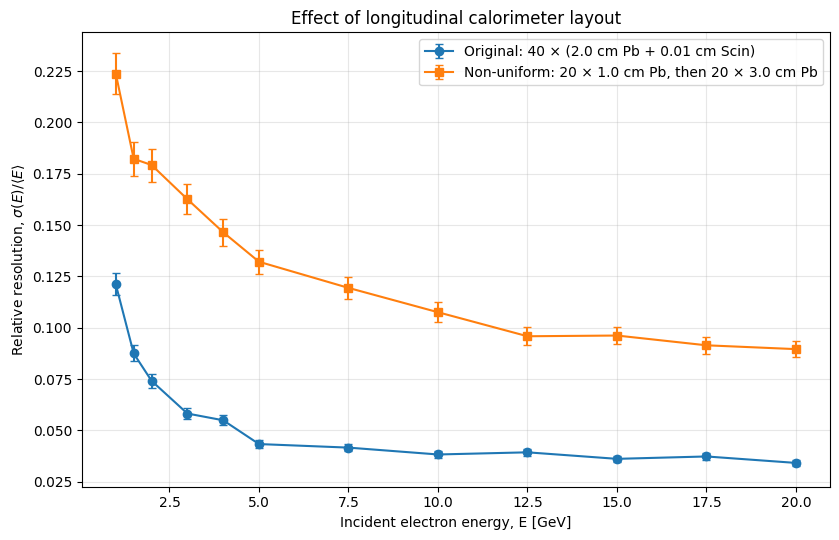

Testing uniform design with 10 lead-scintillator pairs
Testing uniform design with 20 lead-scintillator pairs
Testing uniform design with 30 lead-scintillator pairs
Testing uniform design with 40 lead-scintillator pairs


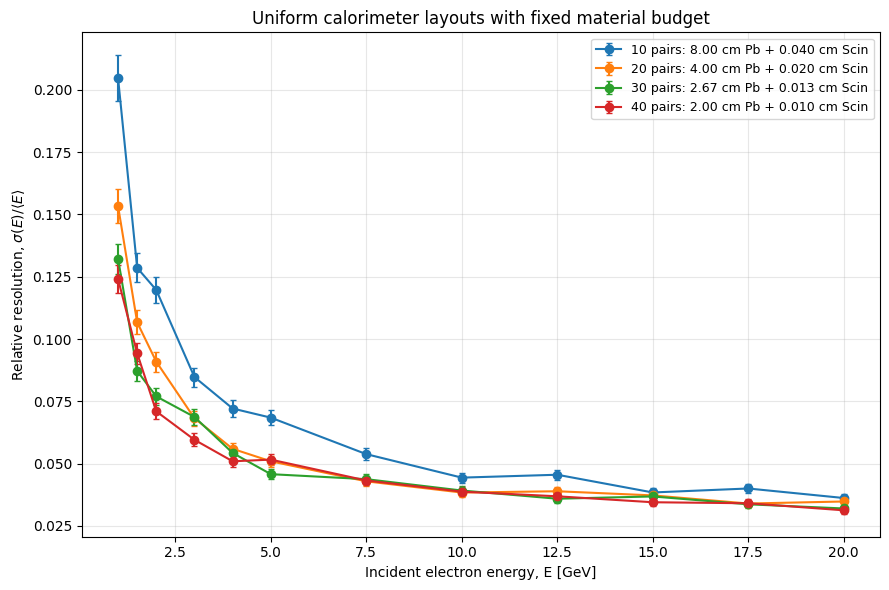

In [17]:
# Modified calorimeter design
#
# Consider a modified design of the calorimeter. You want to improve the resolution of the calorimeter overall. 
# You are allowed to to change the thickness of the individual layers. While you can make fewer layers, you are not allowed to
# make more than the current 40 layers of lead and 40 layers of scintillator. The calorimeter should also have
# the same total thickness as before and have the same amount of lead and scintillator. 
# Use the same values for noise and calibration as above such that direct comparisons can be made. 
#
# 2 marks: Construct a calorimeter with a different layout and demonstrate effect on resolution
# 2 marks: Interpret the given effect (i.e. why is it worse/better everywhere or at low/high energy, or whatever)
# 3 marks: Find a layout that improves on the current layout with equal thickness of lead and scintillator everywhere.

noise_sigma = 2.0
calibration_sigma = 0.03
n_particles_per_energy = 250

particle_energies = np.array(
    [1.0, 1.5, 2.0, 3.0, 4.0, 5.0, 7.5, 10.0, 12.5, 15.0, 17.5, 20.0]
)

study_spectrum = model.Spectrum(
    particle_type=model.Electron,
    min_energy=float(np.min(particle_energies)),
    max_energy=float(np.max(particle_energies)),
)

# Original setup, reconstructed through the general builder.
original_cal = build_uniform_calorimeter(n_pairs=40)
original_sim = model.Simulation(original_cal)

# Non-uniform geometry.
nonuniform_cal = build_nonuniform_calorimeter_v2()
nonuniform_sim = model.Simulation(nonuniform_cal)

original_resolution, original_u_resolution = simulate_resolution_curve(
    original_sim,
    study_spectrum,
    particle_energies,
    n_particles_per_energy,
    noise_sigma,
    calibration_sigma,
    seed=33739374,
)

nonuniform_resolution, nonuniform_u_resolution = simulate_resolution_curve(
    nonuniform_sim,
    study_spectrum,
    particle_energies,
    n_particles_per_energy,
    noise_sigma,
    calibration_sigma,
    seed=33739374,
)

fig, ax = plt.subplots(figsize=(8.5, 5.5))

ax.errorbar(
    particle_energies,
    original_resolution,
    yerr=original_u_resolution,
    fmt="o-",
    capsize=3,
    label="Original: 40 × (2.0 cm Pb + 0.01 cm Scin)",
)

ax.errorbar(
    particle_energies,
    nonuniform_resolution,
    yerr=nonuniform_u_resolution,
    fmt="s-",
    capsize=3,
    label="Non-uniform: 10 × 3.0 cm Pb, then 20 × 1.0 cm Pb, then 10 × 3.0 cm Pb",
)

ax.set_xlabel("Incident electron energy, E [GeV]")
ax.set_ylabel(r"Relative resolution, $\sigma(E)/\langle E\rangle$")
ax.set_title("Effect of longitudinal calorimeter layout")
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

# Test uniform designs
uniform_pair_counts = [10, 20, 30, 40]
uniform_results = {}

for n_pairs in uniform_pair_counts:
    print(f"Testing uniform design with {n_pairs} lead-scintillator pairs")

    calorimeter = build_uniform_calorimeter(n_pairs)
    simulation = model.Simulation(calorimeter)

    resolution, u_resolution = simulate_resolution_curve(
        simulation,
        study_spectrum,
        particle_energies,
        n_particles_per_energy,
        noise_sigma,
        calibration_sigma,
        seed=30000 + n_pairs,
    )

    uniform_results[n_pairs] = {
        "resolution": resolution,
        "uncertainty": u_resolution,
    }

fig, ax = plt.subplots(figsize=(9, 6))

for n_pairs in uniform_pair_counts:
    lead_thickness = 80.0 / n_pairs
    scintillator_thickness = 0.40 / n_pairs

    ax.errorbar(
        particle_energies,
        uniform_results[n_pairs]["resolution"],
        yerr=uniform_results[n_pairs]["uncertainty"],
        marker="o",
        linestyle="-",
        capsize=2,
        label=(
            f"{n_pairs} pairs: "
            f"{lead_thickness:.2f} cm Pb + "
            f"{scintillator_thickness:.3f} cm Scin"
        ),
    )

ax.set_xlabel("Incident electron energy, E [GeV]")
ax.set_ylabel(r"Relative resolution, $\sigma(E)/\langle E\rangle$")
ax.set_title("Uniform calorimeter layouts with fixed material budget")
ax.grid(alpha=0.3)
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()


Calorimeter depth: 142.9 X0
Estimated energy for 95% containment depth to equal calorimeter depth: log10(E / GeV) = 53.3
Simulating 10 GeV electrons
Simulating 20 GeV electrons
Simulating 50 GeV electrons
Simulating 100 GeV electrons
Simulating 200 GeV electrons
Simulating 500 GeV electrons
Simulating 1000 GeV electrons
Simulating 2000 GeV electrons


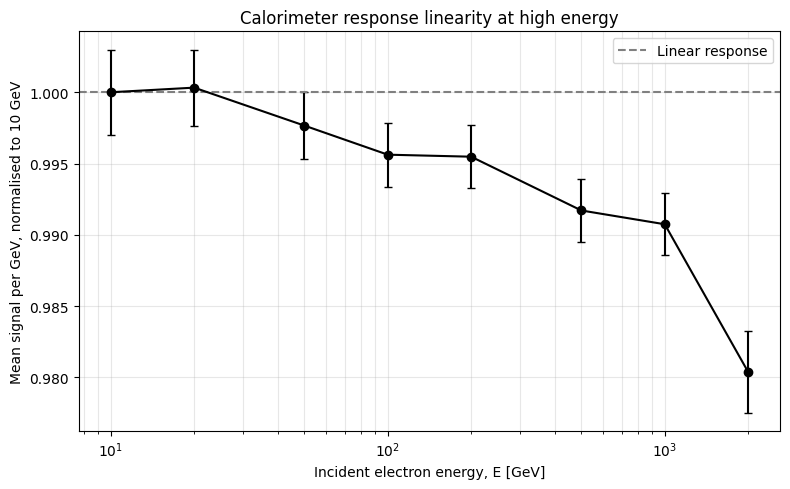

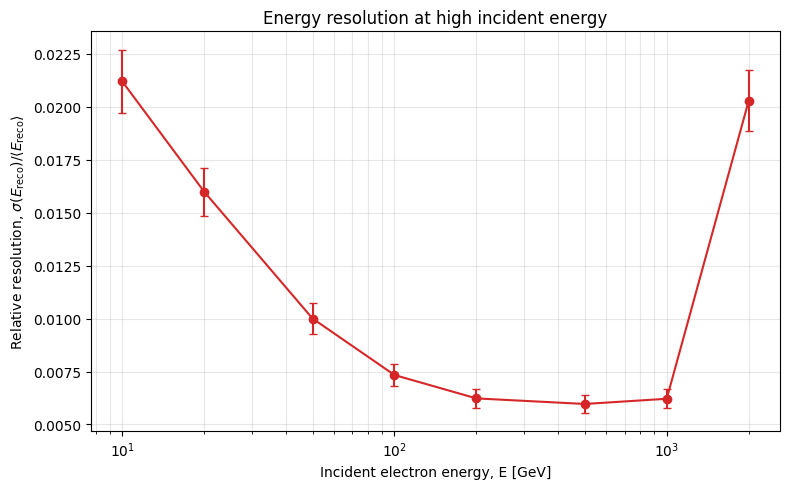

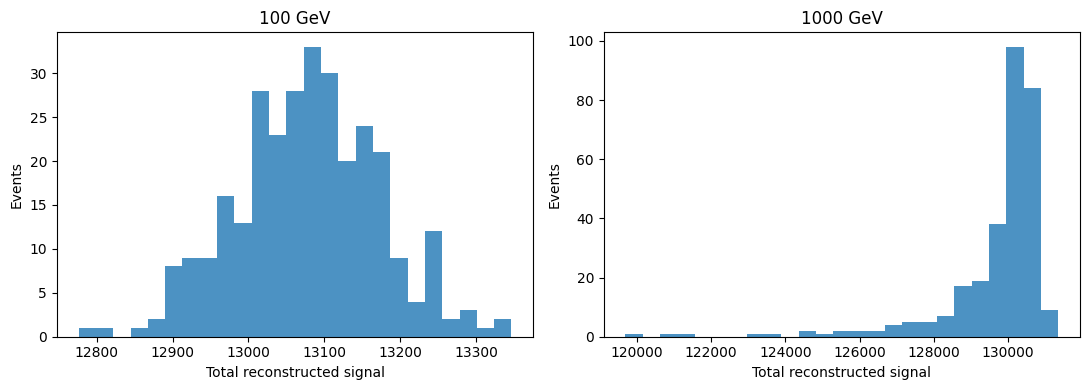

In [20]:
# Punch through
#
# Now revert to the original layout of the layers. Make an investigation of how high energies the calorimeter can 
# measure before the resolution is badly affected by punch through  (i.e. when particles are not fully absorbed).

n_pairs = 40
lead_thickness = 2.0  # cm per lead layer
scintillator_thickness = 0.01  # cm per scintillator layer

# Representative physical values.
X0_lead = 0.56  # cm
X0_scintillator = 43.0  # cm
Ec_lead = 6.9  # MeV
Z_lead = 82

calorimeter_depth_X0 = n_pairs * (
    lead_thickness / X0_lead + scintillator_thickness / X0_scintillator
)

constant_95 = 9.6 + 0.08 * Z_lead

# For an electron:
# t95 = ln(E/Ec) - 1 + 9.6 + 0.08Z
# Therefore ln(E/Ec) = calorimeter_depth_X0 + 1 - constant_95
log_energy_ratio = calorimeter_depth_X0 + 1.0 - constant_95

# Report log10 energy because the direct energy is astronomically large.
log10_energy_MeV = math.log10(Ec_lead) + log_energy_ratio / math.log(10)
log10_energy_GeV = log10_energy_MeV - 3.0

print(f"Calorimeter depth: {calorimeter_depth_X0:.1f} X0")
print(
    "Estimated energy for 95% containment depth to equal calorimeter depth: "
    f"log10(E / GeV) = {log10_energy_GeV:.1f}"
)

punchthrough_energies = np.array(
    [10.0, 20.0, 50.0, 100.0, 200.0, 500.0, 1000.0, 2000.0]
)

n_particles_punchthrough = 100

punchthrough_spectrum = model.Spectrum(
    particle_type=model.Electron,
    min_energy=float(np.min(punchthrough_energies)),
    max_energy=float(np.max(punchthrough_energies)),
)

mean_signals = []
u_mean_signals = []
punchthrough_resolutions = []
u_punchthrough_resolutions = []

for beam_energy in punchthrough_energies:
    print(f"Simulating {beam_energy:.0f} GeV electrons")

    electrons = punchthrough_spectrum.discrete(
        n_particles=n_particles_punchthrough, energy=float(beam_energy)
    )

    ionisations = sim.simulate_sample(electrons, deadcellfraction=0.0)

    reconstructed_signals = np.sum(ionisations, axis=1)

    mean_signal = np.mean(reconstructed_signals)
    signal_std = np.std(reconstructed_signals, ddof=1)

    resolution = signal_std / mean_signal
    u_resolution = resolution / np.sqrt(2 * (n_particles_punchthrough - 1))

    mean_signals.append(mean_signal)
    u_mean_signals.append(signal_std / np.sqrt(n_particles_punchthrough))
    punchthrough_resolutions.append(resolution)
    u_punchthrough_resolutions.append(u_resolution)

mean_signals = np.array(mean_signals)
u_mean_signals = np.array(u_mean_signals)
punchthrough_resolutions = np.array(punchthrough_resolutions)
u_punchthrough_resolutions = np.array(u_punchthrough_resolutions)

response_per_gev = mean_signals / punchthrough_energies
normalised_response = response_per_gev / response_per_gev[0]

# Approximate propagated relative uncertainty.
u_normalised_response = normalised_response * np.sqrt(
    (u_mean_signals / mean_signals)**2
    + (u_mean_signals[0] / mean_signals[0])**2
)

fig, ax = plt.subplots(figsize=(8, 5))

ax.errorbar(
    punchthrough_energies,
    normalised_response,
    yerr=u_normalised_response,
    fmt="o-",
    capsize=3,
    color="black"
)

ax.axhline(
    1.0,
    color="grey",
    linestyle="--",
    label="Linear response"
)

ax.set_xscale("log")
ax.set_xlabel("Incident electron energy, E [GeV]")
ax.set_ylabel("Mean signal per GeV, normalised to 10 GeV")
ax.set_title("Calorimeter response linearity at high energy")
ax.grid(alpha=0.3, which="both")
ax.legend()

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))

ax.errorbar(
    punchthrough_energies,
    punchthrough_resolutions,
    yerr=u_punchthrough_resolutions,
    fmt="o-",
    capsize=3,
    color="tab:red"
)

ax.set_xscale("log")
ax.set_xlabel("Incident electron energy, E [GeV]")
ax.set_ylabel(r"Relative resolution, $\sigma(E_{\rm reco})/\langle E_{\rm reco}\rangle$")
ax.set_title("Energy resolution at high incident energy")
ax.grid(alpha=0.3, which="both")

plt.tight_layout()
plt.show()

compare_energies = [100.0, 1000.0]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, beam_energy in zip(axes, compare_energies):
    electrons = punchthrough_spectrum.discrete(
        n_particles=300,
        energy=beam_energy
    )

    ionisations = sim.simulate_sample(
        electrons,
        deadcellfraction=0.0
    )

    reconstructed_signals = np.sum(ionisations, axis=1)

    ax.hist(reconstructed_signals, bins=25, color="tab:blue", alpha=0.8)
    ax.set_title(f"{beam_energy:.0f} GeV")
    ax.set_xlabel("Total reconstructed signal")
    ax.set_ylabel("Events")

plt.tight_layout()
plt.show()

#
# 2 marks: Use the analytic results for the shower penetration to esitmate when punch through will start to happen.
# 2 marks: Experimentally investigate at which energy the punch through will start to happen.